# **AI Bootcamp – Week 9 | Day 2 Lab**

# Image Generation Workflows

## Objectives

In this lab, you will explore advanced image generation workflows using Stable Diffusion. Unlike Day 1, where images were generated only from text prompts, today you will learn how to transform existing images, edit specific regions, guide image generation using structural information, and explore text-to-video generation.

By the end of this lab, you will be able to:

- Generate images using Image-to-Image (img2img)
- Understand how the Strength parameter affects generated images
- Edit images using Inpainting
- Guide image generation with ControlNet
- Explore text-to-video generation
- Improve prompts through systematic experimentation

# Step 1 – Enable GPU

Stable Diffusion models require GPU acceleration for efficient execution.

Before continuing:

1. Click **Runtime**
2. Select **Change runtime type**
3. Choose **T4 GPU**
4. Click **Save**

Run the following code to verify that your GPU is available.

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU NOT Available")

GPU Available
Tesla T4


# Step 2 – Install Required Libraries

Today's lab requires several additional libraries.

Run the following cell.



In [2]:
!pip -q install diffusers transformers accelerate safetensors opencv-python-headless

# Step 3 – Import Libraries


Complete the missing imports below.

Hint:

You will need

- torch
- numpy
- PIL
- matplotlib
- load_image
- export_to_video

In [3]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers.utils import load_image, export_to_video

# Image-to-Image (img2img)

Unlike Day 1, today's generation starts with an existing image.

Instead of creating a completely new image, Stable Diffusion modifies the original while preserving some of its structure.

The amount of change is controlled by the **Strength** parameter.
# Load the Image-to-Image Pipeline


Complete the missing code.

Model name:

runwayml/stable-diffusion-v1-5

In [5]:
from diffusers import StableDiffusionImg2ImgPipeline

pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe_img2img = pipe_img2img.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

# Load the Sample Image

Run the following cell to download the sample image.

Feel free to swap in your own by uploading it to Colab and loading it with Image.open().

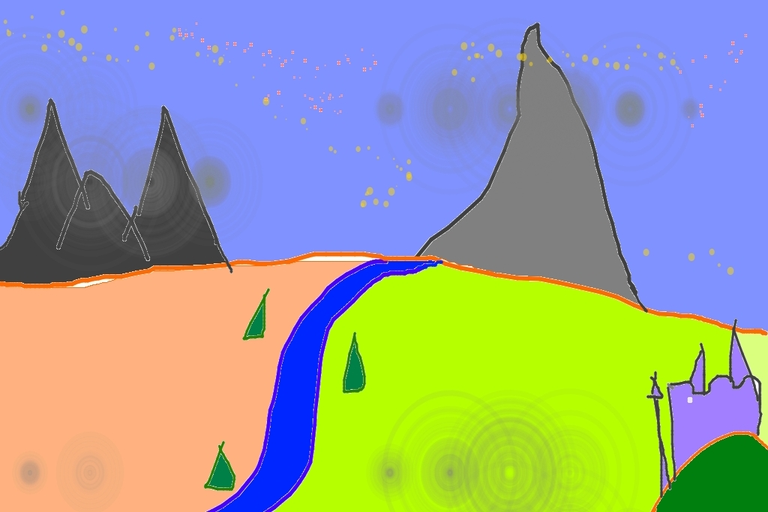

In [6]:
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
init_image = load_image(url).resize((768, 512))
init_image

 Experiment with the Strength Parameter

The **Strength** parameter determines how much the original image is modified.

Lower values preserve more of the original image.

Higher values generate a more dramatically changed image.


Generate the image using:

- Strength = 0.3
- Strength = 0.6
- Strength = 0.9

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

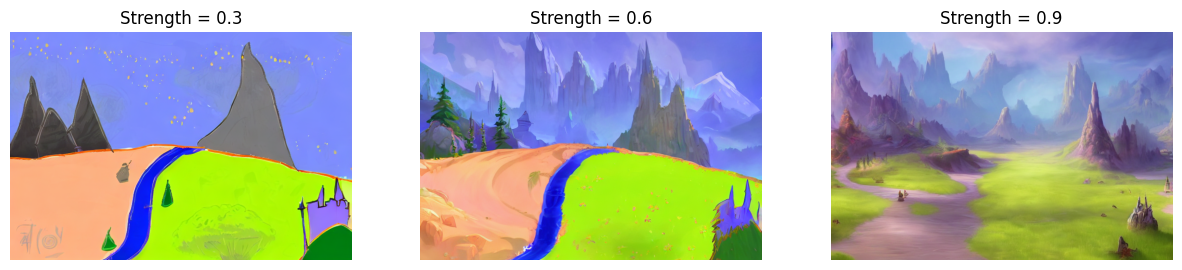

In [7]:
#write your code here
prompt = "a fantasy landscape, trending on artstation"

strengths = [0.3, 0.6, 0.9]
results = []

for s in strengths:
    image = pipe_img2img(
        prompt=prompt,
        image=init_image,
        strength=s,
        guidance_scale=7.5
    ).images[0]
    results.append(image)

fig, axes = plt.subplots(1, len(strengths), figsize=(15, 5))
for ax, img, s in zip(axes, results, strengths):
    ax.imshow(img)
    ax.set_title(f"Strength = {s}")
    ax.axis("off")
plt.show()

## Reflection

1. Which strength preserved the original image best?

2. Which strength produced the largest transformation?

3. Which value would you choose if the client wanted only small edits?

#answer here
Which strength preserved the original image best?
Strength = 0.3

Which strength produced the largest transformation?
Strength = 0.9

Which value would you choose if the client wanted only small edits?
Strength = 0.3

#  Inpainting

Instead of changing the whole image, Inpainting edits only the masked region.

The white region of the mask is regenerated.

The black region remains unchanged.

Load the Inpainting Pipeline


Complete the code below.

In [8]:
from diffusers import StableDiffusionInpaintPipeline

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
)

pipe_inpaint = pipe_inpaint.to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Load an image and its mask.

The mask is white where you want new content generated, and black where the original should stay untouched.

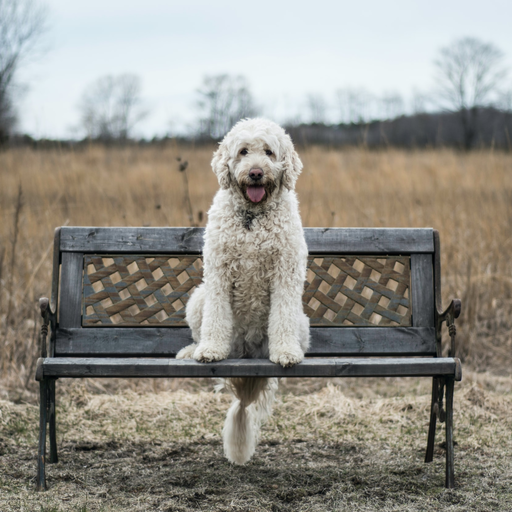

In [10]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

init_image

 Regenerate the masked region.

 **prompt =** "a majestic tiger sitting on a bench"

  0%|          | 0/50 [00:00<?, ?it/s]

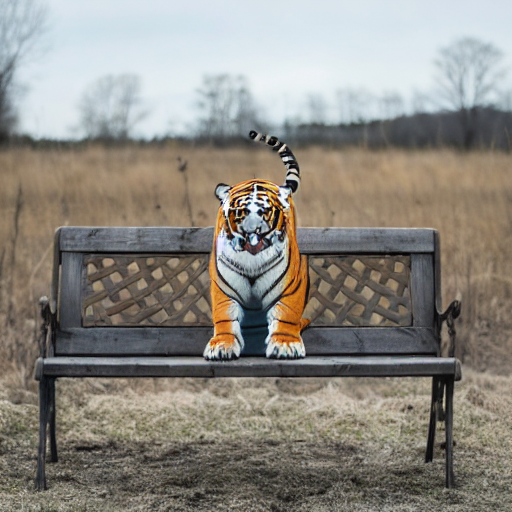

In [12]:
#write your code here
prompt = "a majestic tiger sitting on a bench"

inpainted_image = pipe_inpaint(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    guidance_scale=7.5,
    num_inference_steps=50
).images[0]

inpainted_image

##**Discussion**
    • Does the edited region blend naturally with the rest of the image?
    • What happens if you make the prompt vague vs. very specific?

**Does the edited region blend naturally with the rest of the image?**
Yes, mostly. The colors and lighting match the background field well, and the tiger looks like it's really sitting on the bench. The only issue is the front legs look a bit odd/unnatural, which is a common problem with inpainting.
**What happens if you make the prompt vague vs. very specific?**
A vague prompt (like "an animal") gives random, unpredictable results you might not even get a tiger. A specific prompt (like "a majestic tiger sitting on a bench") gives much better control and consistently generates what you asked for, but it can sometimes cause small errors

 # **ControlNet**

 Install and load ControlNet

In [13]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Create a Canny edge map from a reference image

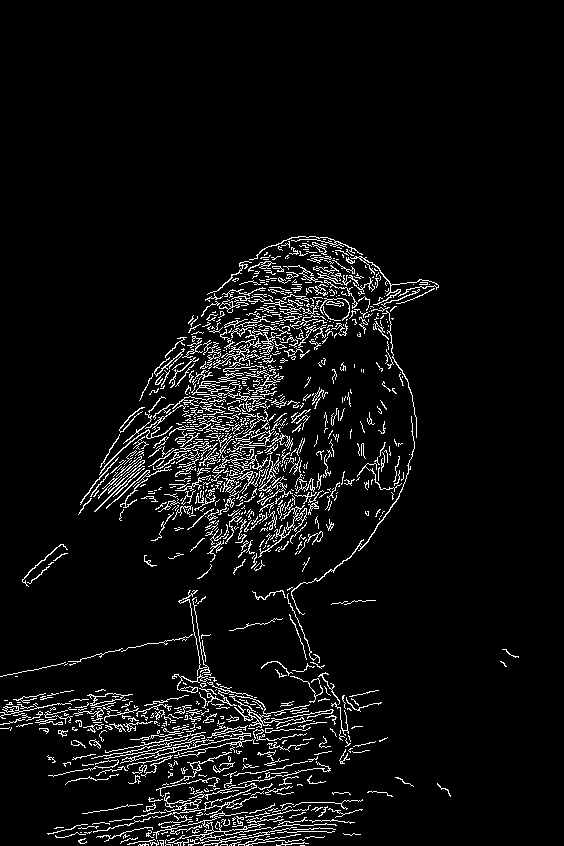

In [14]:
url = "https://huggingface.co/lllyasviel/sd-controlnet-canny/resolve/main/images/bird.png"
ref_image = load_image(url)

#write your code here
image_np = np.array(ref_image)

low_threshold = 100
high_threshold = 200

canny_edges = cv2.Canny(image_np, low_threshold, high_threshold)
canny_edges = canny_edges[:, :, None]
canny_edges = np.concatenate([canny_edges, canny_edges, canny_edges], axis=2)

canny_image = Image.fromarray(canny_edges)
canny_image

Generate guided by the edge map.

prompt = "a colorful parrot, highly detailed, studio lighting"

  0%|          | 0/30 [00:00<?, ?it/s]

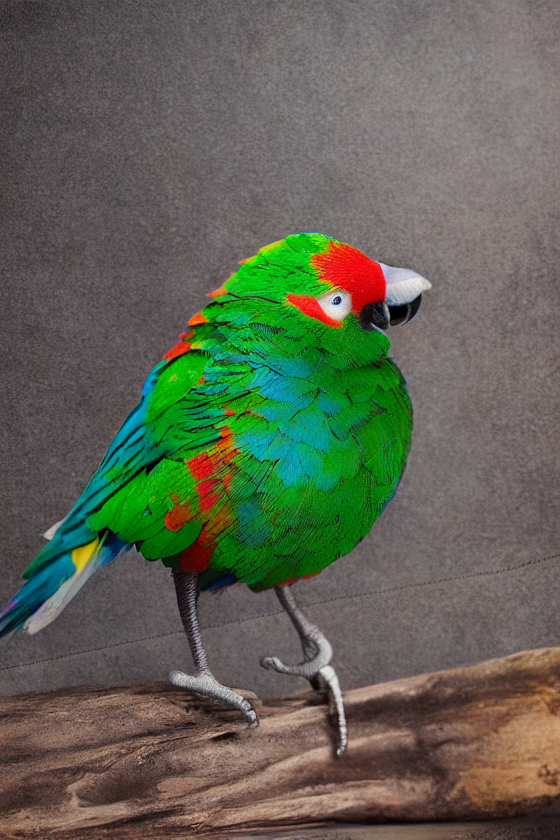

In [18]:
#write your code here
prompt = "a colorful parrot, highly detailed, studio lighting"

controlnet_output = pipe_cn(
    prompt=prompt,
    image=canny_image,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

controlnet_output

# **Text-to-Video Exploration**

Load a lightweight text-to-video model

In [19]:
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

pipe_video = DiffusionPipeline.from_pretrained(
    "damo-vilab/text-to-video-ms-1.7b",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe_video.scheduler = DPMSolverMultistepScheduler.from_config(pipe_video.scheduler.config)
pipe_video.enable_model_cpu_offload()

model_index.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Generate a short clip

In [20]:
prompt = "a golden retriever running on a beach at sunset"

video_frames = pipe_video(prompt, num_inference_steps=25).frames[0]
video_path = export_to_video(video_frames)
video_path

  0%|          | 0/25 [00:00<?, ?it/s]

'/tmp/tmp2zptcwj9.mp4'

Download the file from the Colab file browser (folder icon on the left) to watch it, or display it inline:

In [21]:
from IPython.display import Video
Video(video_path, embed=True)

Compare against a hosted demo.

Try the same prompt on one public text-to-video demo (e.g. a Hugging Face Space).

Note differences in quality, duration, and consistency.
# **Discussion**
    • How does video generation time compare to a single image?
    • What inconsistencies or artifacts do you notice across frames?

**How does video generation time compare to a single image?**
Video takes much longer than a single image because the model has to make many frames (not just one) and make them match each other. Even on a GPU, it took a few minutes.
**What inconsistencies or artifacts do you notice across frames?**
The motion looks decent overall (dog running on the beach), but there's a watermark-like text showing in every frame. The legs and tail look a bit blurry/flickery since they're moving fast. Also, the very first frame (thumbnail) looks slightly weird/distorted compared to the rest of the video.

## Compare against a hosted demo.

In [2]:
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler
import torch

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
pipe_compare = DiffusionPipeline.from_pretrained(
    "cerspense/zeroscope_v2_576w",
    torch_dtype=torch.float16
)
pipe_compare.scheduler = DPMSolverMultistepScheduler.from_config(pipe_compare.scheduler.config)
pipe_compare.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--cerspense--zeroscope_v2_576w/snapshots/6963642a64dbefa93663d1ecebb4ceda2d9ecb28/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--cerspense--zeroscope_v2_576w/snapshots/6963642a64dbefa93663d1ecebb4ceda2d9ecb28/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--cerspense--zeroscope_v2_576w/snapshots/6963642a64dbefa93663d1ecebb4ceda2d9ecb28/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--cerspense--zeroscope_v2_576w/snapshots/6963642a64dbefa93663d1ecebb4ceda2d9ecb28/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after 

In [7]:
from diffusers.utils import export_to_video

prompt = "a golden retriever running on a beach at sunset"

video_frames_compare = pipe_compare(
    prompt,
    num_inference_steps=20,
    height=256,
    width=256,
    num_frames=16
).frames[0]

video_path_compare = export_to_video(video_frames_compare)
video_path_compare

  0%|          | 0/20 [00:00<?, ?it/s]

'/tmp/tmpgeb_kza7.mp4'

In [8]:
from IPython.display import Video
Video(video_path_compare, embed=True)

# Comparison
| Aspect | damo-vilab (original) | zeroscope_v2_576w (comparison) |
|---|---|---|
| **Quality** | Clear subject, decent lighting, watermark artifact | Sharper, more polished, good sunset lighting, no watermark |
| **Motion/Action** | Dog is genuinely running, mid-stride | Dog appears mostly stationary/walking  the "running" action wasn't captured |
| **Consistency** | Some flicker on fast-moving legs | Very stable frame-to-frame, but at the cost of motion |
| **Duration/settings** | 25 steps, more frames | Reduced to 16 frames/20 steps due to GPU memory limits |

The second model produced visually higher-quality individual frames (better lighting, no watermark) but failed to represent the actual "running" action from the prompt — the dog remains largely static. This highlights a common trade-off in video diffusion: reducing frame count and resolution (needed here due to GPU memory limits)